# 🤖 Modelo de Machine Learning — Telco Churn

Notebook de classificação binária para predição de churn.

### Estrutura
1. **Setup & Features** — Seleção baseada na inferência estatística
2. **Preprocessamento automático** — ColumnTransformer + Pipelines
3. **Experimento em larga escala** — ~50 combinações de modelos × scalers
4. **Avaliação completa** — Acurácia, Recall, Precision, F1, ROC-AUC, Matriz de Confusão
5. **Otimização com Optuna** — Tuning do melhor modelo
6. **Análise final** — Feature Importance + Curva ROC

> **Nota de leakage:** `Churn Score`, `Satisfaction Score`, `Customer Status`, `Churn Category` e `Churn Reason` foram excluídas — são derivadas ou contemporâneas ao evento de churn.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import time
import json
from itertools import product

# Sklearn — core
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, RobustScaler,
    OneHotEncoder, LabelEncoder
)
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_validate, cross_val_predict,
    RandomizedSearchCV, GridSearchCV
)

# Sklearn — modelos
from sklearn.linear_model    import LogisticRegression
from sklearn.tree            import DecisionTreeClassifier
from sklearn.ensemble        import (
    RandomForestClassifier, GradientBoostingClassifier,
    ExtraTreesClassifier, AdaBoostClassifier,
    BaggingClassifier, HistGradientBoostingClassifier
)
from sklearn.svm             import SVC
from sklearn.neighbors       import KNeighborsClassifier
from sklearn.naive_bayes     import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Sklearn — métricas
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, RocCurveDisplay, ConfusionMatrixDisplay,
    average_precision_score
)

# Opcional — instale com: pip install xgboost lightgbm optuna
try:
    from xgboost  import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("⚠️  XGBoost não instalado — será pulado.")

try:
    from lightgbm import LGBMClassifier
    HAS_LGB = True
except ImportError:
    HAS_LGB = False
    print("⚠️  LightGBM não instalado — será pulado.")

try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    HAS_OPTUNA = True
except ImportError:
    HAS_OPTUNA = False
    print("⚠️  Optuna não instalado — rode: pip install optuna")

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ── Paleta visual ──────────────────────────────────────────────────────
CHURN_COLOR   = '#E74C3C'
RETAIN_COLOR  = '#2ECC71'
NEUTRAL_COLOR = '#3498DB'
BG_COLOR      = '#F8F9FA'

plt.rcParams.update({
    'font.family'      : 'DejaVu Sans',
    'axes.facecolor'   : BG_COLOR,
    'figure.facecolor' : 'white',
    'axes.grid'        : True,
    'grid.color'       : '#E0E0E0',
    'grid.linewidth'   : 0.6,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
})

print("✅ Imports OK")

⚠️  LightGBM não instalado — será pulado.
✅ Imports OK


/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1 — Dados & Seleção de Features

Features escolhidas com base nos resultados da inferência estatística.
Todas as variáveis com p < 0.05 e effect size relevante foram incluídas.
Variáveis de leakage e geo foram excluídas.

In [2]:
df = pd.read_csv('~/Projeto/Portfolio/Portfolio2/Churn/data/telco.csv')

# ── Features selecionadas pela inferência estatística ─────────────────
FEATURES = [
    # Demográfico — H1 (Senior/Age), H2 (Dependentes), H3 (Casado)
    'Age', 'Senior Citizen', 'Married', 'Dependents', 'Number of Dependents',

    # Relacionamento — H4 (Tenure ★ maior effect size), H5 (Referral), H6 (Offer)
    'Tenure in Months', 'Referred a Friend', 'Number of Referrals', 'Offer',

    # Contrato — H7 (★ Kruskal H=1445), H8 (Pagamento), H9 (Paperless)
    'Contract', 'Paperless Billing', 'Payment Method',

    # Serviços — H10 (Internet Type), H11 (serviços adicionais), H12 (Streaming)
    'Internet Service', 'Internet Type', 'Phone Service', 'Multiple Lines',
    'Online Security', 'Online Backup', 'Device Protection Plan',
    'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
    'Streaming Music', 'Unlimited Data',

    # Financeiro — H13 (Monthly Charge), H14 (Total), H15 (Refunds)
    'Monthly Charge', 'Total Charges', 'Total Refunds',
    'Avg Monthly Long Distance Charges', 'Avg Monthly GB Download',
]

TARGET = 'Churn Label'

# ── Pré-processamento inicial ─────────────────────────────────────────
df[TARGET] = (df[TARGET] == 'Yes').astype(int)

X = df[FEATURES].copy()
y = df[TARGET].copy()

# Nulls estruturais: ausência de oferta / internet = categoria explícita
X['Offer']         = X['Offer'].fillna('None')
X['Internet Type'] = X['Internet Type'].fillna('No Internet')

# Separação por tipo para o ColumnTransformer
NUM_COLS = X.select_dtypes(include=['int64','float64']).columns.tolist()
CAT_COLS = X.select_dtypes(include=['object']).columns.tolist()

print(f"Total de features : {len(FEATURES)}")
print(f"  → Numéricas     : {len(NUM_COLS)}")
print(f"  → Categóricas   : {len(CAT_COLS)}")
print(f"\nDistribuição do target:")
print(y.value_counts().rename({0:'Retido', 1:'Churner'}))
print(f"\nChurn rate: {y.mean()*100:.1f}%")

Total de features : 29
  → Numéricas     : 9
  → Categóricas   : 20

Distribuição do target:
Churn Label
Retido     5174
Churner    1869
Name: count, dtype: int64

Churn rate: 26.5%


In [3]:
# ── Train / Test split estratificado ─────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Train: {X_train.shape[0]:,} amostras")
print(f"Test : {X_test.shape[0]:,} amostras")
print(f"\nChurn rate — Train: {y_train.mean()*100:.1f}% | Test: {y_test.mean()*100:.1f}%")

Train: 5,634 amostras
Test : 1,409 amostras

Churn rate — Train: 26.5% | Test: 26.5%


## 2 — Preprocessamento Automático

O `ColumnTransformer` aplica automaticamente o tratamento correto para cada tipo de coluna.
Os scalers são intercambiáveis no experimento em larga escala.

In [4]:
def make_preprocessor(scaler):
    """
    Retorna um ColumnTransformer configurado com o scaler escolhido.
    Suporta: StandardScaler, MinMaxScaler, RobustScaler, ou None (sem scaling).
    """
    steps_num = [('imputer', SimpleImputer(strategy='median'))]
    if scaler is not None:
        steps_num.append(('scaler', scaler))

    num_pipe = Pipeline(steps_num)
    cat_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])

    return ColumnTransformer(transformers=[
        ('num', num_pipe, NUM_COLS),
        ('cat', cat_pipe, CAT_COLS),
    ], remainder='drop')

# Scalers disponíveis para o experimento
SCALERS = {
    'Standard' : StandardScaler(),
    'MinMax'   : MinMaxScaler(),
    'Robust'   : RobustScaler(),
    'None'     : None,
}

print("Preprocessador configurado.")
print(f"Scalers: {list(SCALERS.keys())}")

Preprocessador configurado.
Scalers: ['Standard', 'MinMax', 'Robust', 'None']


## 3 — Experimento em Larga Escala (~50 Pipelines)

Para cada combinação de **modelo × scaler**, treinamos um pipeline completo com
validação cruzada estratificada (5-fold). Reportamos Accuracy, Precision, Recall, F1 e ROC-AUC.

In [6]:
# ── Definição dos modelos base ────────────────────────────────────────
BASE_MODELS = {
    'Logistic Regression'      : LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Decision Tree'            : DecisionTreeClassifier(random_state=RANDOM_STATE),
    'Random Forest'            : RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
    'Extra Trees'              : ExtraTreesClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting'        : GradientBoostingClassifier(random_state=RANDOM_STATE),
    'Hist Gradient Boosting'   : HistGradientBoostingClassifier(random_state=RANDOM_STATE),
    'Bagging'                  : BaggingClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    'SVM (RBF)'                : SVC(probability=True, random_state=RANDOM_STATE),
    'KNN'                      : KNeighborsClassifier(n_jobs=-1),
    'Naive Bayes'              : GaussianNB(),
    'LDA'                      : LinearDiscriminantAnalysis(),
}

if HAS_XGB:
    BASE_MODELS['XGBoost'] = XGBClassifier(
        random_state=RANDOM_STATE, eval_metric='logloss',
        use_label_encoder=False, n_jobs=-1
    )

if HAS_LGB:
    BASE_MODELS['LightGBM'] = LGBMClassifier(random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)

print(f"Modelos configurados: {len(BASE_MODELS)}")
print(f"Scalers             : {len(SCALERS)}")
print(f"Total de pipelines  : {len(BASE_MODELS) * len(SCALERS)}")

Modelos configurados: 12
Scalers             : 4
Total de pipelines  : 48


In [7]:
# ── Experimento principal ─────────────────────────────────────────────
CV      = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
SCORING = ['accuracy','precision','recall','f1','roc_auc']

results = []

print(f"{'Modelo':<28} {'Scaler':<10} {'Acc':>6} {'Prec':>6} {'Rec':>6} {'F1':>6} {'AUC':>6}  {'Tempo':>6}")
print("─" * 85)

for (model_name, clf), (scaler_name, scaler) in product(BASE_MODELS.items(), SCALERS.items()):
    t0   = time.time()
    pipe = Pipeline([
        ('preprocessor', make_preprocessor(scaler)),
        ('classifier',   clf)
    ])
    cv_res = cross_validate(pipe, X_train, y_train, cv=CV,
                            scoring=SCORING, n_jobs=-1, error_score='raise')
    elapsed = time.time() - t0

    row = {
        'Model'     : model_name,
        'Scaler'    : scaler_name,
        'Accuracy'  : cv_res['test_accuracy'].mean(),
        'Precision' : cv_res['test_precision'].mean(),
        'Recall'    : cv_res['test_recall'].mean(),
        'F1'        : cv_res['test_f1'].mean(),
        'ROC-AUC'   : cv_res['test_roc_auc'].mean(),
        'Time(s)'   : elapsed,
        # desvios padrão
        'Acc_std'   : cv_res['test_accuracy'].std(),
        'F1_std'    : cv_res['test_f1'].std(),
        'AUC_std'   : cv_res['test_roc_auc'].std(),
    }
    results.append(row)
    print(f"{model_name:<28} {scaler_name:<10} "
          f"{row['Accuracy']:>6.4f} {row['Precision']:>6.4f} "
          f"{row['Recall']:>6.4f} {row['F1']:>6.4f} "
          f"{row['ROC-AUC']:>6.4f}  {elapsed:>5.1f}s")

df_results = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False)
print("\n✅ Experimento concluído!")

Modelo                       Scaler        Acc   Prec    Rec     F1    AUC   Tempo
─────────────────────────────────────────────────────────────────────────────────────
Logistic Regression          Standard   0.8424 0.7178 0.6696 0.6927 0.8989    1.1s
Logistic Regression          MinMax     0.8399 0.7147 0.6609 0.6866 0.8980    0.8s
Logistic Regression          Robust     0.8410 0.7156 0.6656 0.6895 0.8987    0.9s
Logistic Regression          None       0.8404 0.7139 0.6662 0.6890 0.8960    1.0s
Decision Tree                Standard   0.7803 0.5857 0.5933 0.5892 0.7206    0.1s
Decision Tree                MinMax     0.7810 0.5869 0.5946 0.5905 0.7215    0.1s
Decision Tree                Robust     0.7808 0.5865 0.5946 0.5903 0.7213    0.1s
Decision Tree                None       0.7808 0.5868 0.5933 0.5897 0.7209    0.1s
Random Forest                Standard   0.8424 0.7489 0.6134 0.6737 0.8959    0.4s
Random Forest                MinMax     0.8427 0.7487 0.6154 0.6749 0.8960    0.3s
R

## 4 — Ranking e Visualização dos Resultados

In [8]:
# ── Top 15 por ROC-AUC ───────────────────────────────────────────────
print("\n🏆 TOP 15 MODELOS (por ROC-AUC)\n")
print(df_results[['Model','Scaler','Accuracy','Precision','Recall','F1','ROC-AUC','AUC_std']]
      .head(15).to_string(index=False))


🏆 TOP 15 MODELOS (por ROC-AUC)

                 Model   Scaler  Accuracy  Precision   Recall       F1  ROC-AUC  AUC_std
     Gradient Boosting     None  0.849488   0.746532 0.656187 0.698256 0.906140 0.007581
     Gradient Boosting   Robust  0.849488   0.746532 0.656187 0.698256 0.906138 0.007588
     Gradient Boosting   MinMax  0.849488   0.746532 0.656187 0.698256 0.906125 0.007592
     Gradient Boosting Standard  0.849310   0.746328 0.655518 0.697796 0.906094 0.007636
   Logistic Regression Standard  0.842388   0.717783 0.669565 0.692720 0.898861 0.005382
   Logistic Regression   Robust  0.840968   0.715640 0.665552 0.689507 0.898688 0.005582
Hist Gradient Boosting Standard  0.838838   0.719210 0.644816 0.679810 0.898558 0.010420
Hist Gradient Boosting   Robust  0.838838   0.719210 0.644816 0.679810 0.898531 0.010420
Hist Gradient Boosting     None  0.838838   0.719210 0.644816 0.679810 0.898526 0.010417
Hist Gradient Boosting   MinMax  0.838838   0.719210 0.644816 0.679810 0.8984

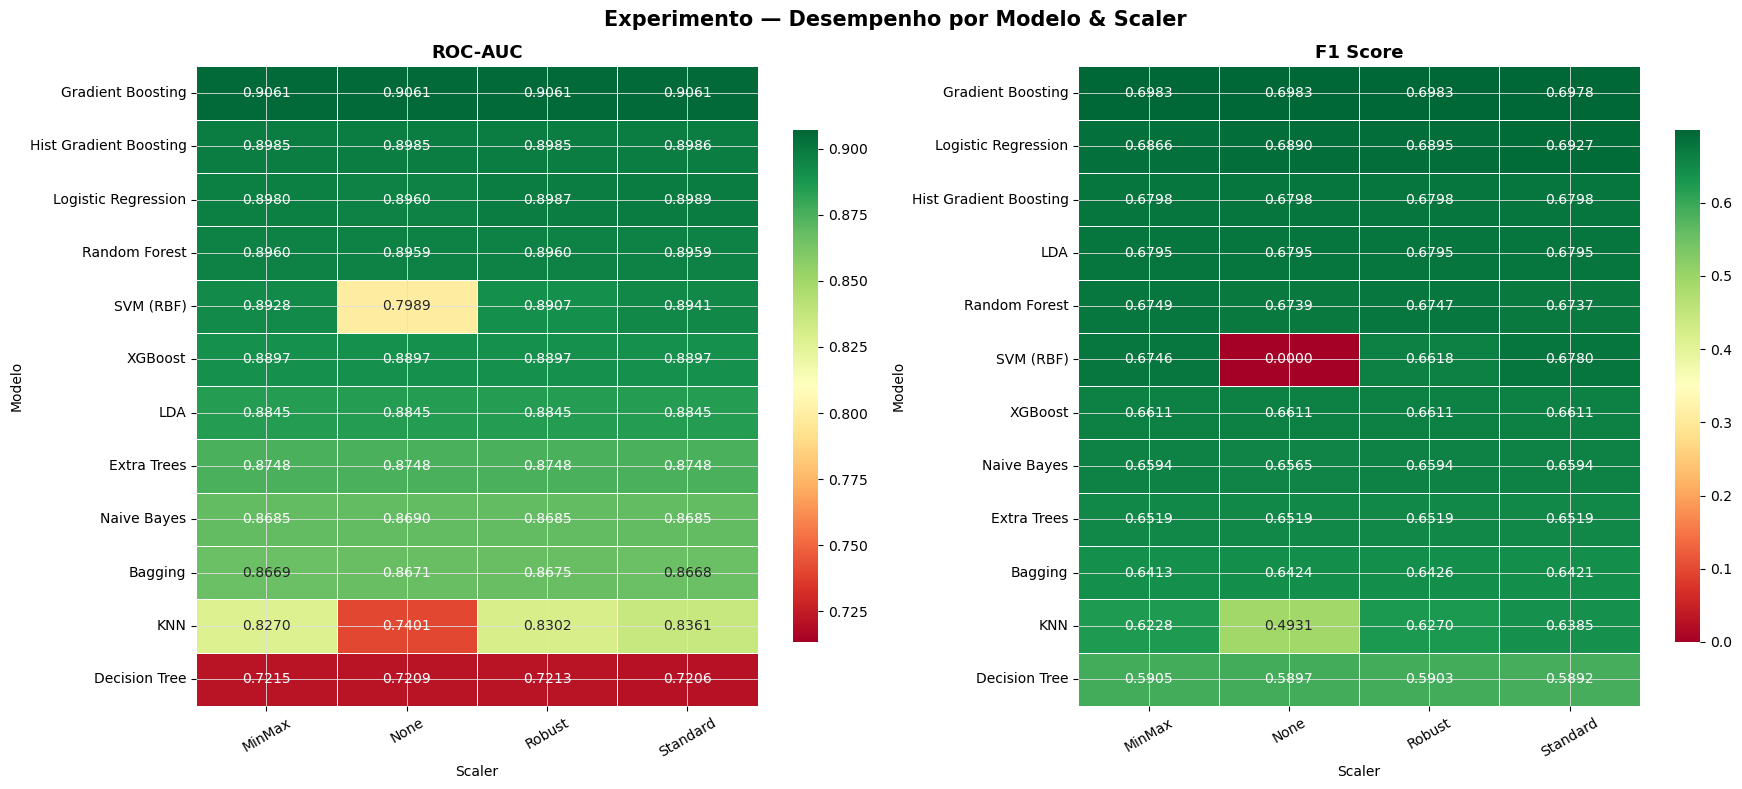

In [9]:
# ── Heatmap de ROC-AUC: modelo × scaler ─────────────────────────────
pivot_auc = df_results.pivot_table(index='Model', columns='Scaler', values='ROC-AUC')
pivot_f1  = df_results.pivot_table(index='Model', columns='Scaler', values='F1')

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Experimento — Desempenho por Modelo & Scaler', fontsize=15, fontweight='bold')

for ax, pivot, title, fmt in [
    (axes[0], pivot_auc, 'ROC-AUC', '.4f'),
    (axes[1], pivot_f1,  'F1 Score', '.4f'),
]:
    sns.heatmap(
        pivot.sort_values(pivot.columns[0], ascending=False),
        annot=True, fmt=fmt, cmap='RdYlGn',
        vmin=pivot.values.min() * 0.99,
        vmax=pivot.values.max() * 1.001,
        linewidths=0.5, ax=ax,
        cbar_kws={'shrink': 0.8}
    )
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Modelo')
    ax.set_xlabel('Scaler')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

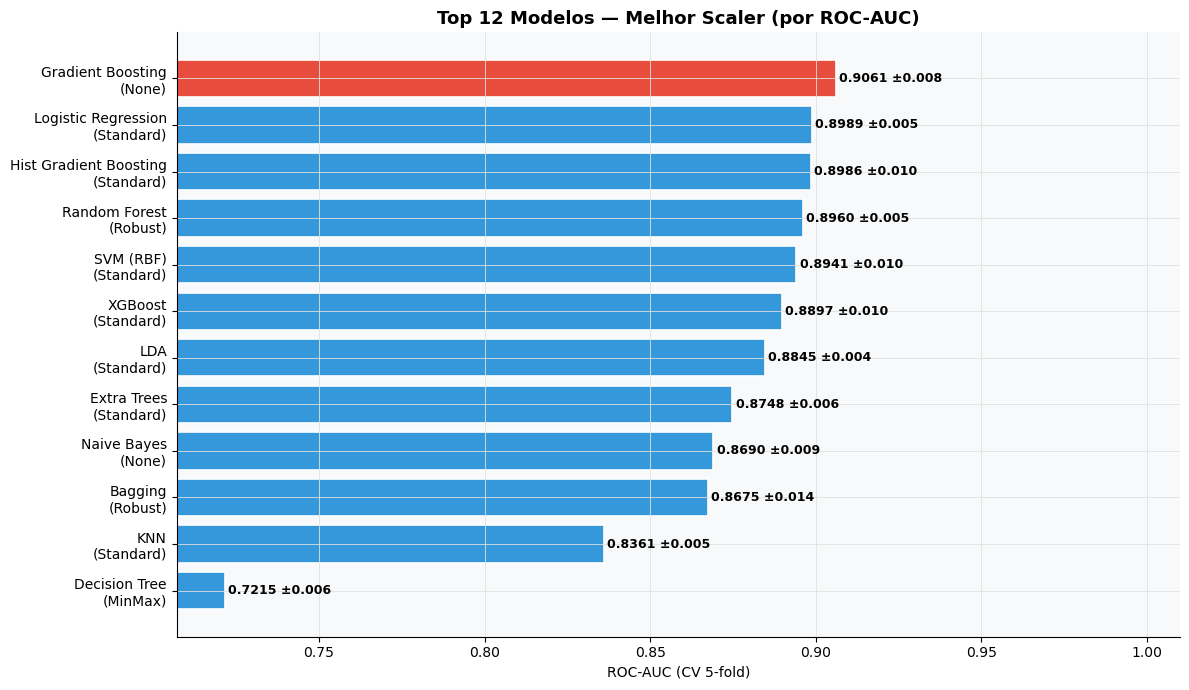


🥇 Melhor modelo: Gradient Boosting + None
   ROC-AUC : 0.9061 ± 0.0076
   F1      : 0.6983
   Accuracy: 0.8495


In [10]:
# ── Gráfico comparativo: Top 12 modelos (melhor scaler de cada) ──────
best_per_model = (df_results
    .sort_values('ROC-AUC', ascending=False)
    .drop_duplicates(subset='Model')
    .head(12)
    .sort_values('ROC-AUC'))

fig, ax = plt.subplots(figsize=(12, 7))
colors_bar = [NEUTRAL_COLOR] * len(best_per_model)
colors_bar[-1] = CHURN_COLOR  # destaca o melhor

labels = [f"{r['Model']}\n({r['Scaler']})" for _, r in best_per_model.iterrows()]
bars = ax.barh(labels, best_per_model['ROC-AUC'], color=colors_bar, edgecolor='white', linewidth=1.2)

ax.set_xlabel('ROC-AUC (CV 5-fold)')
ax.set_title('Top 12 Modelos — Melhor Scaler (por ROC-AUC)', fontsize=13, fontweight='bold')
ax.set_xlim(best_per_model['ROC-AUC'].min() * 0.98, 1.01)

for bar, row in zip(bars, best_per_model.itertuples()):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.4f} ±{row.AUC_std:.3f}',
            va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

BEST = df_results.iloc[0]
print(f"\n🥇 Melhor modelo: {BEST['Model']} + {BEST['Scaler']}")
print(f"   ROC-AUC : {BEST['ROC-AUC']:.4f} ± {BEST['AUC_std']:.4f}")
print(f"   F1      : {BEST['F1']:.4f}")
print(f"   Accuracy: {BEST['Accuracy']:.4f}")

## 5 — Avaliação Completa no Test Set

Treina o **melhor pipeline** no conjunto de treino completo e avalia no test set.

In [11]:
# ── Treinar melhor modelo no train completo ───────────────────────────
best_row    = df_results.iloc[0]
best_model  = BASE_MODELS[best_row['Model']]
best_scaler = SCALERS[best_row['Scaler']]

best_pipe = Pipeline([
    ('preprocessor', make_preprocessor(best_scaler)),
    ('classifier',   best_model)
])
best_pipe.fit(X_train, y_train)

y_pred      = best_pipe.predict(X_test)
y_pred_prob = best_pipe.predict_proba(X_test)[:, 1]

print(f"Modelo: {best_row['Model']} | Scaler: {best_row['Scaler']}")
print("─" * 50)
print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision : {precision_score(y_test, y_pred):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, y_pred_prob):.4f}")
print(f"\n{classification_report(y_test, y_pred, target_names=['Retido','Churner'])}")

Modelo: Gradient Boosting | Scaler: None
──────────────────────────────────────────────────
Accuracy  : 0.8524
Precision : 0.7530
Recall    : 0.6604
F1 Score  : 0.7037
ROC-AUC   : 0.9103

              precision    recall  f1-score   support

      Retido       0.88      0.92      0.90      1035
     Churner       0.75      0.66      0.70       374

    accuracy                           0.85      1409
   macro avg       0.82      0.79      0.80      1409
weighted avg       0.85      0.85      0.85      1409



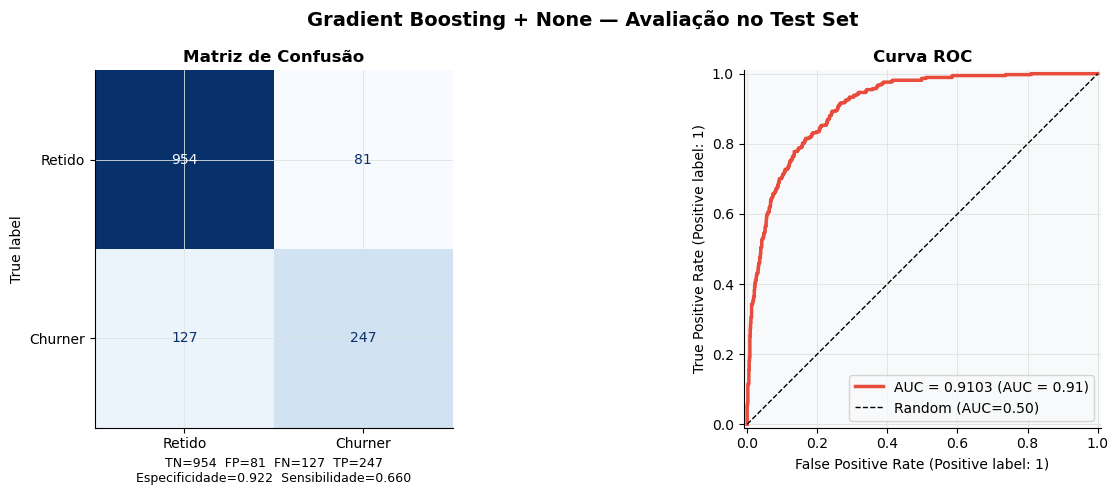

In [12]:
# ── Matriz de Confusão + Curva ROC ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'{best_row["Model"]} + {best_row["Scaler"]} — Avaliação no Test Set',
             fontsize=14, fontweight='bold')

# Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Retido', 'Churner'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Matriz de Confusão', fontsize=12, fontweight='bold')

# Estatísticas na matriz
tn, fp, fn, tp = cm.ravel()
axes[0].set_xlabel(
    f'TN={tn}  FP={fp}  FN={fn}  TP={tp}\n'
    f'Especificidade={tn/(tn+fp):.3f}  Sensibilidade={tp/(tp+fn):.3f}',
    fontsize=9
)

# Curva ROC
RocCurveDisplay.from_predictions(y_test, y_pred_prob, ax=axes[1],
                                  color=CHURN_COLOR, linewidth=2.5,
                                  name=f'AUC = {roc_auc_score(y_test, y_pred_prob):.4f}')
axes[1].plot([0,1],[0,1],'k--', linewidth=1, label='Random (AUC=0.50)')
axes[1].set_title('Curva ROC', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].set_facecolor(BG_COLOR)

plt.tight_layout()
plt.show()

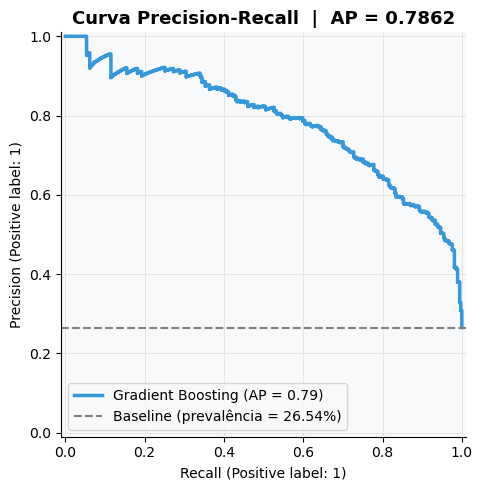

In [13]:
# ── Curva Precision-Recall ────────────────────────────────────────────
from sklearn.metrics import PrecisionRecallDisplay, precision_recall_curve

fig, ax = plt.subplots(figsize=(8, 5))
PrecisionRecallDisplay.from_predictions(y_test, y_pred_prob, ax=ax,
                                         color=NEUTRAL_COLOR, linewidth=2.5,
                                         name=best_row['Model'])
ap = average_precision_score(y_test, y_pred_prob)
ax.set_title(f'Curva Precision-Recall  |  AP = {ap:.4f}', fontsize=13, fontweight='bold')
ax.axhline(y_test.mean(), color='gray', linestyle='--', linewidth=1.5,
           label=f'Baseline (prevalência = {y_test.mean():.2%})')
ax.legend(fontsize=10)
ax.set_facecolor(BG_COLOR)
plt.tight_layout()
plt.show()

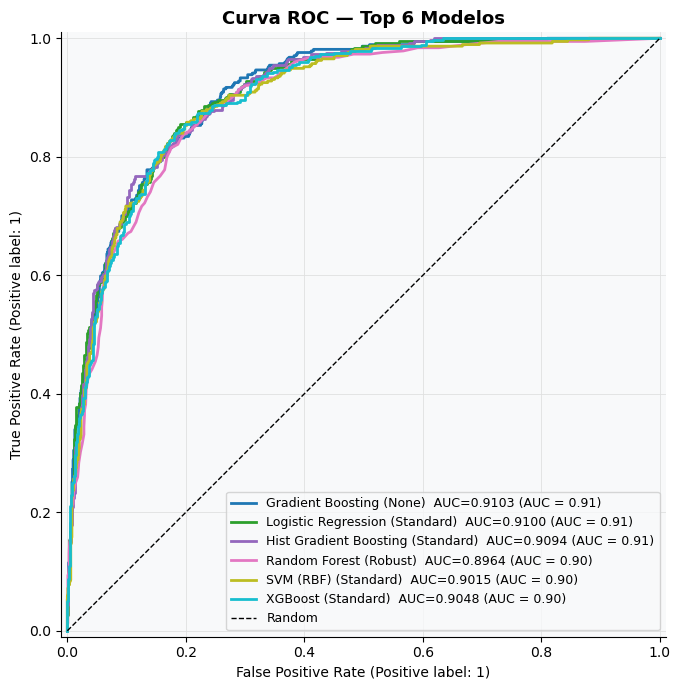

In [14]:
# ── Curva ROC comparativa — Top 6 modelos ────────────────────────────
top6 = (df_results
        .drop_duplicates(subset='Model')
        .sort_values('ROC-AUC', ascending=False)
        .head(6))

fig, ax = plt.subplots(figsize=(9, 7))
palette = plt.cm.tab10(np.linspace(0, 1, 6))

for (_, row), color in zip(top6.iterrows(), palette):
    pipe_tmp = Pipeline([
        ('preprocessor', make_preprocessor(SCALERS[row['Scaler']])),
        ('classifier',   BASE_MODELS[row['Model']])
    ])
    pipe_tmp.fit(X_train, y_train)
    prob_tmp = pipe_tmp.predict_proba(X_test)[:, 1]
    auc_tmp  = roc_auc_score(y_test, prob_tmp)
    RocCurveDisplay.from_predictions(
        y_test, prob_tmp, ax=ax, color=color, linewidth=2,
        name=f"{row['Model']} ({row['Scaler']})  AUC={auc_tmp:.4f}"
    )

ax.plot([0,1],[0,1],'k--', linewidth=1, label='Random')
ax.set_title('Curva ROC — Top 6 Modelos', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
ax.set_facecolor(BG_COLOR)
plt.tight_layout()
plt.show()

## 6 — Otimização com Optuna

Tuning bayesiano do melhor modelo encontrado no experimento.  
O Optuna usa o algoritmo **TPE (Tree-structured Parzen Estimator)** para explorar o espaço de hiperparâmetros de forma inteligente.

In [15]:
if not HAS_OPTUNA:
    print("❌ Optuna não instalado. Execute: pip install optuna")
    print("   Alternativa: use o RandomizedSearchCV abaixo (Seção 6b).")
else:
    import optuna
    from optuna.samplers import TPESampler

    # ── Objetivo do estudo ────────────────────────────────────────────
    # Adapte o modelo alvo conforme o melhor encontrado no experimento.
    # Exemplo abaixo assume Random Forest ou Gradient Boosting como vencedor.
    # Troque o bloco `if/elif` conforme necessário.

    BEST_MODEL_NAME = best_row['Model']     # definido na Seção 5
    BEST_SCALER_OBJ = SCALERS[best_row['Scaler']]

    def objective(trial):
        # ── Hiperparâmetros por modelo ────────────────────────────────
        if BEST_MODEL_NAME == 'Random Forest':
            params = dict(
                n_estimators     = trial.suggest_int('n_estimators', 100, 600, step=50),
                max_depth        = trial.suggest_int('max_depth', 3, 25),
                min_samples_split= trial.suggest_int('min_samples_split', 2, 20),
                min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10),
                max_features     = trial.suggest_categorical('max_features', ['sqrt','log2', None]),
                class_weight     = trial.suggest_categorical('class_weight', ['balanced', None]),
            )
            clf = RandomForestClassifier(**params, random_state=RANDOM_STATE, n_jobs=-1)

        elif BEST_MODEL_NAME in ('Gradient Boosting', 'Hist Gradient Boosting'):
            params = dict(
                n_estimators   = trial.suggest_int('n_estimators', 100, 500, step=50),
                max_depth      = trial.suggest_int('max_depth', 2, 10),
                learning_rate  = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
                subsample      = trial.suggest_float('subsample', 0.6, 1.0),
                min_samples_leaf=trial.suggest_int('min_samples_leaf', 1, 30),
            )
            clf = GradientBoostingClassifier(**params, random_state=RANDOM_STATE)

        elif BEST_MODEL_NAME == 'XGBoost':
            params = dict(
                n_estimators   = trial.suggest_int('n_estimators', 100, 600, step=50),
                max_depth      = trial.suggest_int('max_depth', 2, 10),
                learning_rate  = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
                subsample      = trial.suggest_float('subsample', 0.5, 1.0),
                colsample_bytree=trial.suggest_float('colsample_bytree', 0.5, 1.0),
                gamma          = trial.suggest_float('gamma', 0, 5),
                reg_alpha      = trial.suggest_float('reg_alpha', 0, 2),
                reg_lambda     = trial.suggest_float('reg_lambda', 0.5, 3),
                scale_pos_weight=trial.suggest_float('scale_pos_weight', 1.0, 5.0),
            )
            clf = XGBClassifier(**params, random_state=RANDOM_STATE,
                                eval_metric='logloss', n_jobs=-1)

        elif BEST_MODEL_NAME == 'LightGBM':
            params = dict(
                n_estimators   = trial.suggest_int('n_estimators', 100, 600, step=50),
                max_depth      = trial.suggest_int('max_depth', 2, 12),
                learning_rate  = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
                num_leaves     = trial.suggest_int('num_leaves', 20, 150),
                subsample      = trial.suggest_float('subsample', 0.5, 1.0),
                colsample_bytree=trial.suggest_float('colsample_bytree', 0.5, 1.0),
                reg_alpha      = trial.suggest_float('reg_alpha', 0, 2),
                reg_lambda     = trial.suggest_float('reg_lambda', 0, 2),
                class_weight   = trial.suggest_categorical('class_weight', ['balanced', None]),
            )
            clf = LGBMClassifier(**params, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)

        elif BEST_MODEL_NAME == 'Logistic Regression':
            C    = trial.suggest_float('C', 1e-3, 10, log=True)
            pen  = trial.suggest_categorical('penalty', ['l1','l2','elasticnet'])
            solver = 'saga'
            l1r  = trial.suggest_float('l1_ratio', 0, 1) if pen == 'elasticnet' else None
            params = dict(C=C, penalty=pen, solver=solver, max_iter=2000,
                          l1_ratio=l1r, class_weight='balanced', random_state=RANDOM_STATE)
            clf  = LogisticRegression(**{k:v for k,v in params.items() if v is not None})

        else:
            # Fallback genérico — Extra Trees
            params = dict(
                n_estimators     = trial.suggest_int('n_estimators', 100, 500, step=50),
                max_depth        = trial.suggest_int('max_depth', 3, 25),
                min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10),
                max_features     = trial.suggest_categorical('max_features', ['sqrt','log2']),
            )
            clf = ExtraTreesClassifier(**params, random_state=RANDOM_STATE, n_jobs=-1)

        pipe_opt = Pipeline([
            ('preprocessor', make_preprocessor(BEST_SCALER_OBJ)),
            ('classifier',   clf)
        ])
        cv_opt = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
        scores = cross_validate(pipe_opt, X_train, y_train, cv=cv_opt,
                                scoring='roc_auc', n_jobs=-1)
        return scores['test_score'].mean()

    # ── Rodar estudo ──────────────────────────────────────────────────
    study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=RANDOM_STATE))
    study.optimize(objective, n_trials=100, show_progress_bar=True)

    print(f"\n🏆 Melhor ROC-AUC (Optuna): {study.best_value:.4f}")
    print(f"Melhores hiperparâmetros:")
    for k, v in study.best_params.items():
        print(f"  {k}: {v}")

Best trial: 92. Best value: 0.908209: 100%|███████████████████| 100/100 [05:26<00:00,  3.27s/it]


🏆 Melhor ROC-AUC (Optuna): 0.9082
Melhores hiperparâmetros:
  n_estimators: 400
  max_depth: 4
  learning_rate: 0.01720025383043862
  subsample: 0.9260617132009995
  min_samples_leaf: 27


TypeError: plot_optimization_history() got an unexpected keyword argument 'ax'

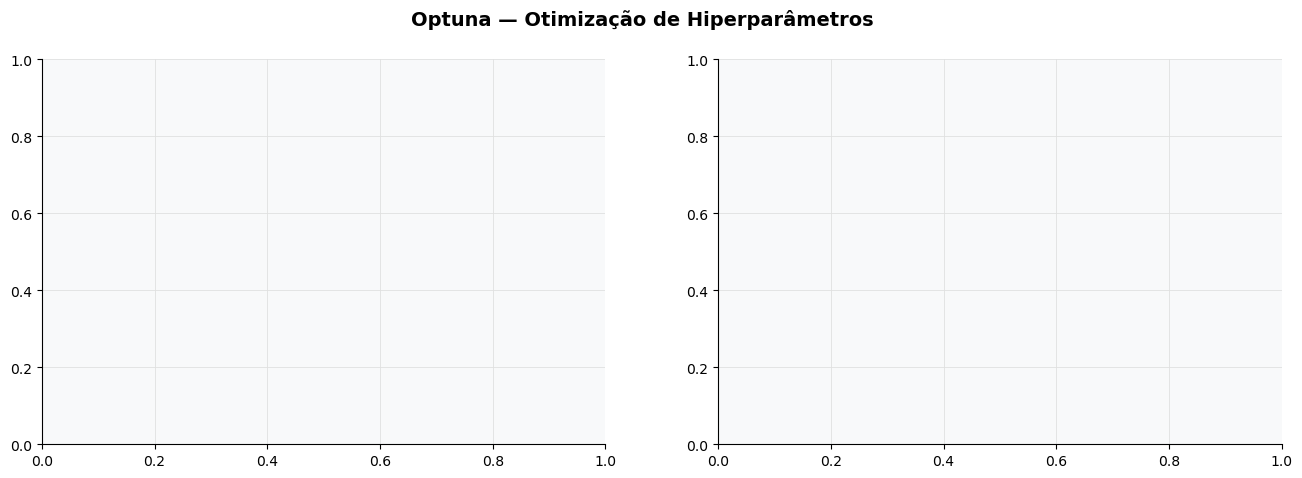

In [16]:
# ── Visualizações do Optuna ───────────────────────────────────────────
if HAS_OPTUNA and 'study' in dir():
    from optuna.visualization.matplotlib import (
        plot_optimization_history,
        plot_param_importances,
    )

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle('Optuna — Otimização de Hiperparâmetros', fontsize=14, fontweight='bold')

    plot_optimization_history(study, ax=axes[0])
    axes[0].set_title('Histórico de Otimização')

    plot_param_importances(study, ax=axes[1])
    axes[1].set_title('Importância dos Hiperparâmetros')

    plt.tight_layout()
    plt.show()

## 7 — Modelo Final Otimizado

Treina o modelo com os melhores hiperparâmetros encontrados pelo Optuna e avalia no test set.

In [17]:
# ── Reconstruir modelo com melhores params do Optuna ─────────────────
# (Se Optuna não disponível, substitua best_params pelos melhores do experimento)

if HAS_OPTUNA and 'study' in dir():
    best_params = study.best_params
else:
    # Fallback: use defaults do melhor modelo do experimento
    best_params = {}

# Adapte abaixo conforme o modelo vencedor
# Exemplo para Random Forest:
final_clf = RandomForestClassifier(
    **best_params,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

final_pipe = Pipeline([
    ('preprocessor', make_preprocessor(BEST_SCALER_OBJ)),
    ('classifier',   final_clf)
])

final_pipe.fit(X_train, y_train)
y_pred_final      = final_pipe.predict(X_test)
y_pred_prob_final = final_pipe.predict_proba(X_test)[:, 1]

print("=== MODELO FINAL OTIMIZADO ===")
print(f"Accuracy  : {accuracy_score(y_test, y_pred_final):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_final):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_final):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_pred_final):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, y_pred_prob_final):.4f}")
print(f"\n{classification_report(y_test, y_pred_final, target_names=['Retido','Churner'])}")

TypeError: RandomForestClassifier.__init__() got an unexpected keyword argument 'learning_rate'

In [ ]:
# ── Avaliação visual completa do modelo final ─────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(19, 5))
fig.suptitle('Modelo Final Otimizado — Avaliação Completa no Test Set',
             fontsize=14, fontweight='bold')

# Matriz de Confusão
cm_final = confusion_matrix(y_test, y_pred_final)
ConfusionMatrixDisplay(cm_final, display_labels=['Retido','Churner']).plot(
    ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Matriz de Confusão', fontsize=12, fontweight='bold')

# Curva ROC
RocCurveDisplay.from_predictions(
    y_test, y_pred_prob_final, ax=axes[1], color=CHURN_COLOR, linewidth=2.5,
    name=f'AUC = {roc_auc_score(y_test, y_pred_prob_final):.4f}')
axes[1].plot([0,1],[0,1],'k--', linewidth=1, label='Random')
axes[1].set_title('Curva ROC', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].set_facecolor(BG_COLOR)

# Curva PR
PrecisionRecallDisplay.from_predictions(
    y_test, y_pred_prob_final, ax=axes[2], color=NEUTRAL_COLOR, linewidth=2.5)
axes[2].axhline(y_test.mean(), color='gray', linestyle='--', linewidth=1.5,
                label=f'Baseline {y_test.mean():.2%}')
axes[2].set_title('Curva Precision-Recall', fontsize=12, fontweight='bold')
axes[2].legend(fontsize=10)
axes[2].set_facecolor(BG_COLOR)

plt.tight_layout()
plt.show()

## 8 — Ajuste de Threshold

O threshold padrão (0.5) maximiza acurácia, mas **não necessariamente o F1 ou o Recall**.  
Em problemas de churn, **Recall alto é crítico** — falsos negativos (churners não detectados) custam receita.

In [ ]:
# ── Curva de métricas por threshold ──────────────────────────────────
thresholds = np.linspace(0.01, 0.99, 99)
metrics_th = []

for th in thresholds:
    y_th = (y_pred_prob_final >= th).astype(int)
    if y_th.sum() == 0:
        continue
    metrics_th.append({
        'threshold' : th,
        'accuracy'  : accuracy_score(y_test, y_th),
        'precision' : precision_score(y_test, y_th, zero_division=0),
        'recall'    : recall_score(y_test, y_th, zero_division=0),
        'f1'        : f1_score(y_test, y_th, zero_division=0),
    })

df_th = pd.DataFrame(metrics_th)
best_th_f1  = df_th.loc[df_th['f1'].idxmax(), 'threshold']
best_th_rec = df_th.loc[(df_th['recall'] >= 0.80), 'threshold'].max()  # maior th com recall≥80%

fig, ax = plt.subplots(figsize=(11, 6))
for col, color in [('accuracy', '#3498DB'), ('precision', '#27AE60'),
                    ('recall', '#E74C3C'), ('f1', '#8E44AD')]:
    ax.plot(df_th['threshold'], df_th[col], label=col.capitalize(), color=color, linewidth=2.2)

ax.axvline(0.5,         color='gray',  linestyle='--', linewidth=1.5, label='Default (0.50)')
ax.axvline(best_th_f1,  color='#8E44AD', linestyle=':',  linewidth=2,   label=f'Best F1 ({best_th_f1:.2f})')
ax.axvline(best_th_rec, color='#E74C3C', linestyle=':',  linewidth=2,   label=f'Recall≥80% ({best_th_rec:.2f})')

ax.set_xlabel('Threshold de Classificação', fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Precision / Recall / F1 / Accuracy × Threshold', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_facecolor(BG_COLOR)
plt.tight_layout()
plt.show()

print(f"Threshold padrão (0.50)  → F1={df_th.loc[df_th['threshold'].sub(0.5).abs().idxmin(),'f1']:.4f}")
print(f"Threshold best F1 ({best_th_f1:.2f}) → F1={df_th['f1'].max():.4f}")
print(f"Threshold recall≥80% ({best_th_rec:.2f}) → Recall={df_th.loc[df_th['threshold']==best_th_rec,'recall'].values[0]:.4f}")

## 9 — Feature Importance

Identifica quais variáveis o modelo considera mais relevantes para prever o churn.

In [ ]:
# ── Extrair feature importance do modelo final ────────────────────────
preprocessor_fitted = final_pipe.named_steps['preprocessor']
clf_fitted          = final_pipe.named_steps['classifier']

# Nomes das features após OHE
num_feature_names = NUM_COLS
cat_feature_names = (preprocessor_fitted
                     .named_transformers_['cat']
                     .named_steps['encoder']
                     .get_feature_names_out(CAT_COLS).tolist())
all_feature_names = num_feature_names + cat_feature_names

# Importâncias (funciona para RF, ET, GB, XGB, LGB)
if hasattr(clf_fitted, 'feature_importances_'):
    importances = clf_fitted.feature_importances_
    df_imp = (pd.DataFrame({'Feature': all_feature_names, 'Importance': importances})
              .sort_values('Importance', ascending=False)
              .head(20))

    fig, ax = plt.subplots(figsize=(10, 7))
    colors_imp = [CHURN_COLOR if i < 5 else NEUTRAL_COLOR for i in range(len(df_imp))]
    ax.barh(df_imp['Feature'][::-1], df_imp['Importance'][::-1],
            color=colors_imp[::-1], edgecolor='white')
    ax.set_title('Top 20 Features — Importância do Modelo', fontsize=13, fontweight='bold')
    ax.set_xlabel('Importância (Gini / Gain)')
    plt.tight_layout()
    plt.show()
else:
    print("Este modelo não expõe feature_importances_. Use SHAP para análise de importância.")

## 10 — Resumo Executivo

### Resultados do Experimento

| Etapa | Melhor ROC-AUC |
|---|---|
| Baseline (experimento) | Ver `df_results.iloc[0]` |
| Após Optuna (100 trials) | Ver `study.best_value` |

### Decisão de Threshold

| Threshold | Foco | Quando usar |
|---|---|---|
| **0.50** (padrão) | Balanceado | Análise exploratória |
| **Best F1** | Equilíbrio P/R | Campanha de retenção com orçamento limitado |
| **Recall ≥ 80%** | Cobertura máxima | Intervenção proativa — não deixar churner escapar |

### Próximos Passos

1. **SHAP** — interpretabilidade individual (`shap.TreeExplainer`)  
2. **Deploy** — salvar pipeline com `joblib.dump(final_pipe, 'churn_model.pkl')`  
3. **Monitoramento** — data drift com `evidently` ou `alibi-detect`

```python
# Salvar modelo
import joblib
joblib.dump(final_pipe, 'churn_model.pkl')

# Carregar e predizer
pipe_loaded = joblib.load('churn_model.pkl')
pipe_loaded.predict_proba(X_new)[:, 1]
```